# Exploration of datasets
## PAN 2023

In [1]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization import datasets
from config import CONFIG
from functools import partial
import gc
import datetime
import textwrap

In [2]:
# pan23 = datasets.Pan23Visualization()
# ds_pan = pan23.load_dataset()
# labels = ds_pan['same']
# display(ds_pan.head())

In [3]:
# labels.value_counts()

In [4]:
# pan23_stats = pan23.dataset_stats()

In [5]:
# pan23.plot_avg_text_length_per_author()
# pan23.plot_text_length_histogram(bins=50)
# pan23.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del pan23
# gc.collect()

## PAN 20

In [6]:
pan20 = datasets.Pan20Visualization()
ds_pan20 = pan20.load_dataset()
labels_pan20 = ds_pan20['same']
display(ds_pan20.head())

,id,fandoms,pair,same,authors
0,6cced668-6e51-5212-873c-717f2bc91ce6,"[Guardians of Ga'Hoole, Hetalia - Axis Powers]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
1,3c6c188a-db28-59aa-8c09-3d0f799ff579,"[Guardians of Ga'Hoole, Warriors]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
2,b0cfa94f-c9ec-5aa5-8331-a5a249b664cf,"[Guardians of Ga'Hoole, Xiaolin Showdown]",[A single tear escaped me as I left. I did hav...,True,"[1446633, 1446633]"
3,e6e86e73-9a7b-58f2-a652-a17b4a1bcabf,"[Hetalia - Axis Powers, Warriors]","[""Ja."" Ludwig kept his gaze upon her, solidly....",True,"[1446633, 1446633]"
4,4fe541af-912e-5a86-81a5-94c6d3891509,"[Hetalia - Axis Powers, Xiaolin Showdown]","[And he did. Slowly, hesitantly...but coming f...",True,"[1446633, 1446633]"


In [7]:
# labels_pan20.value_counts()

In [8]:
pan20_stats = pan20.dataset_stats()

In [9]:
# pan20.plot_text_length_histogram(bins=50)

In [10]:
# def normalize_text(text):
#     stemmer = SnowballStemmer('english')
#     return ' '.join(stemmer.stem(w) for w in text.lower().split())

In [11]:
# FIXME: kernel fails

# impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True)

# preproc_fn = partial(impostor_det.tokenize_char_ngrams, n=4, normalize_ws=True, space_free=True)
# pan20.plot_text_length_histogram(bins=50, preprocess_fn=preproc_fn)

In [12]:
# pan20.plot_avg_text_length_per_author()

In [13]:
# pan20.plot_avg_text_length_per_author(unit='ngrams')

In [14]:
# pan20.boxplots_text_len_ngrams()

In [15]:
# Python garbage collector to release memory
del pan20
gc.collect()

223

## Blog Corpus

In [16]:
blog = datasets.BlogVisualization()

In [17]:
blog_stats = blog.dataset_stats()

In [18]:
blog_df = pd.read_csv(Path(os.getcwd()).resolve().parent / "data/datasets/Blog_corpus/blogtext.csv")
blog_df["date"] = pd.to_datetime(blog_df["date"], format='mixed', dayfirst=True, errors='coerce')
print(blog_df["date"].agg(["min", "max"]))
print('there is actually entries with date= 01,January,1999 and 23,August,2006, i checked it')


min   1999-01-01
max   2006-08-23
Name: date, dtype: datetime64[ns]
there is actually entries with date= 01,January,1999 and 23,August,2006, i checked it


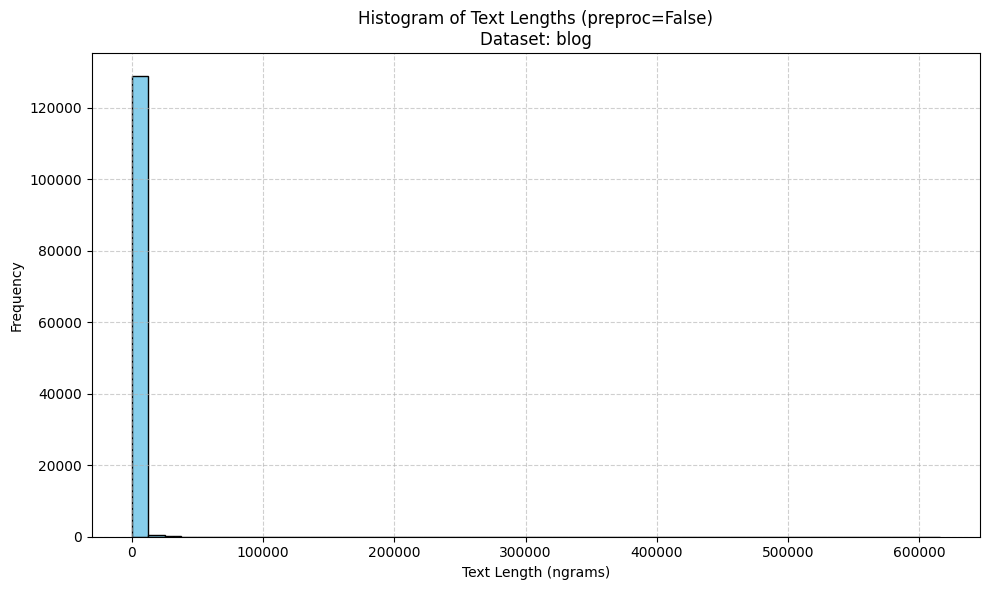

Average length (characters) per text: 1846.20


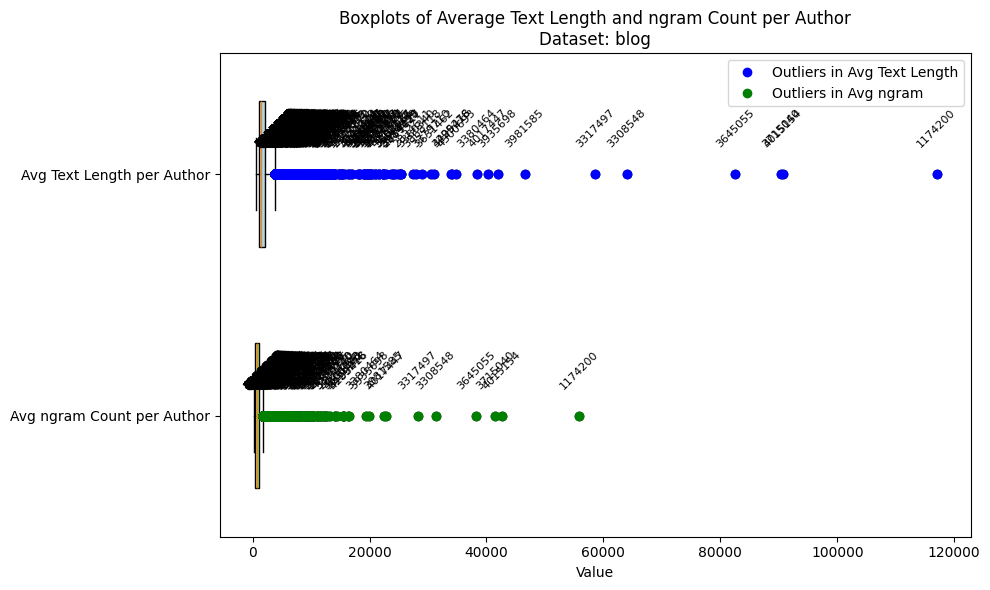

In [19]:
# blog.plot_avg_text_length_per_author()    # too many authors
blog.plot_text_length_histogram(bins=50)    # FIXME: dataset comes already preprocessed
blog.boxplots_text_len_ngrams()

In [20]:
# Python garbage collector to release memory
del blog
gc.collect()

298312

## Gutenberg

In [21]:
gutenberg = datasets.GutenbergVisualization()

In [22]:
# gutenberg_df = gutenberg.load_dataset()
# gutenberg_df

Preprocessing example on MacBeth

In [23]:
imp_det = ImpostorDetector()
# sample_text = gutenberg_df['pair'].iloc[0][0]
sys.path.append(os.path.abspath(".."))

with open(Path(os.getcwd()).resolve().parent / Path(CONFIG.PATH2GUTENBERG).parent / 'Macbeth_William_Shakespeare.txt', 'r') as f:
    sample_text = f.read()
print(textwrap.fill(sample_text, width=80))

ACT I  SCENE I. An open Place.    Thunder and Lightning. Enter three Witches.
FIRST WITCH. When shall we three meet again? In thunder, lightning, or in rain?
SECOND WITCH. When the hurlyburly’s done, When the battle’s lost and won.  THIRD
WITCH. That will be ere the set of sun.  FIRST WITCH. Where the place?  SECOND
WITCH. Upon the heath.  THIRD WITCH. There to meet with Macbeth.  FIRST WITCH. I
come, Graymalkin!  SECOND WITCH. Paddock calls.  THIRD WITCH. Anon.  ALL. Fair
is foul, and foul is fair: Hover through the fog and filthy air.   [_Exeunt._]
SCENE II. A Camp near Forres.   Alarum within. Enter King Duncan, Malcolm,
Donalbain, Lennox, with  Attendants, meeting a bleeding Captain.  DUNCAN. What
bloody man is that? He can report, As seemeth by his plight, of the revolt The
newest state.  MALCOLM. This is the sergeant Who, like a good and hardy soldier,
fought ’Gainst my captivity.—Hail, brave friend! Say to the King the knowledge
of the broil As thou didst leave it.  SOLDIER. Dou

In [24]:
normalized_text = imp_det.preprocess_text(sample_text)
print(textwrap.fill(normalized_text, width=80))

an open place. thunder and lightning. enter three witches. when shall we three
meet again? in thunder, lightning, or in rain? when the hurlyburlys done, when
the battles lost and won. that will be ere the set of sun. where the place? upon
the heath. there to meet with macbeth. i come, graymalkin! paddock calls. anon.
fair is foul, and foul is fair: hover through the fog and filthy air. exeunt. a
camp near forres. alarum within. enter king duncan, malcolm, donalbain, lennox,
with attendants, meeting a bleeding captain. what bloody man is that? he can
report, as seemeth by his plight, of the revolt the newest state. this is the
sergeant who, like a good and hardy soldier, fought gainst my captivity.hail,
brave friend! say to the king the knowledge of the broil as thou didst leave it.
doubtful it stood; as two spent swimmers that do cling together and choke their
art. the merciless macdonwald (worthy to be a rebel, for to that the multiplying
villainies of nature do swarm upon him) from t

In [25]:
gutenberg_stats = gutenberg.dataset_stats()

In [26]:
# gutenberg.plot_avg_text_length_per_author()
# gutenberg.plot_text_length_histogram(bins=50)
# gutenberg.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del gutenberg
# gc.collect()

## PAN 25

In [27]:
# pan25 = datasets.Pan25Visualization()
# pan25_stats = pan25.dataset_stats()

## Webis Koppel dataset

In [28]:
# koppel_webis = datasets.KoppelWebisVisualization()
# koppel_webis_stats = koppel_webis.dataset_stats()

In [29]:
# koppel_webis.plot_avg_text_length_per_author()
# koppel_webis.plot_text_length_histogram(bins=50)
# koppel_webis.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del koppel_webis
# gc.collect()

## Compare datasets

In [30]:
combined_stats = pd.concat([pan20_stats, blog_stats, gutenberg_stats,# pan23_stats, koppel_webis_stats, # pan25_stats
                            ], axis=0, ignore_index=True)    # concat rows
combined_stats.set_index('dataset', inplace=True)  # set dataset as index
save_path = Path.cwd().parent / CONFIG.SAVE_PATH / 'all_data' / 'statistics' 
save_path.mkdir(parents=True, exist_ok=True)  # create directory if it doesn't exist
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
combined_stats.to_csv(save_path / f'combined_stats_{timestamp}.csv', float_format="%.2f")

In [31]:
display(combined_stats)

,num_pairs,num_authors,num_same_pairs,num_different_pairs,avg_text_len,min_text_len,max_text_len,std_text_len,median_text_len
dataset,,,,,,,,,
pan20,66912,52778,35620,31292,21435.528343,20670,296887,2685.487659,21284.0
blog,64771,18961,33639,31132,1846.198932,501,615409,3461.739196,1244.0
gutenberg,36,4,15,21,293840.111111,14092,1176438,339991.164798,139370.0
